<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA2_LAB2/RA2_Laboratorio_N%C2%B0_2_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Sentimientos en Reseñas de Google Play
## Comparativa de Modelos: Bag of Words vs. Redes Neuronales Secuenciales

---

**Proyecto:** Automatización del análisis de sentimientos para reseñas de aplicaciones móviles  
**Dominio:** Procesamiento de Lenguaje Natural (NLP) — Clasificación Multiclase  
**Framework:** TensorFlow / Keras + Scikit-Learn  
**Autor** :`Acosta Alex`, `Bareiro Santiago`, `Borges Agustin`

---

### Resumen Ejecutivo

Una consultora de análisis de producto enfrenta el problema de escala: la revisión manual de miles de reseñas mensuales de Google Play es inviable operacionalmente. El objetivo de este notebook es diseñar, entrenar y evaluar comparativamente tres arquitecturas de clasificación de texto para mapear cada reseña a una de tres categorías de sentimiento:

| Etiqueta | Rango de Estrellas | Clase Numérica |
|---|---|---|
| **Negativo** | 1 – 2 estrellas | `0` |
| **Neutral**  | 3 estrellas      | `1` |
| **Positivo** | 4 – 5 estrellas  | `2` |

La estrategia experimental sigue el eje **Hipótesis → Experimento → Conclusión**, escalando progresivamente en complejidad: desde un modelo estadístico clásico (TF-IDF + Regresión Logística) hasta arquitecturas neurales profundas que explotan la estructura secuencial del lenguaje (BiLSTM y CNN-1D).

---
## Sección 1 — Configuración del Entorno y Análisis Exploratorio de Datos (EDA)

### 1.1 Importación de Librerías

In [1]:
# ─── Reproducibilidad ────────────────────────────────────────────────────────
import os, random
import numpy as np
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ─── Manipulación de datos ────────────────────────────────────────────────────
import pandas as pd
import re
from collections import Counter

# ─── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
sns.set_theme(style='whitegrid', palette='muted')

# ─── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Dropout, Bidirectional, LSTM,
    Conv1D, GlobalMaxPooling1D, Dense, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("✓ Entorno configurado correctamente.")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2
✓ Entorno configurado correctamente.


### 1.2 Carga del Dataset

In [2]:
# Descargar el dataset si se ejecuta en Colab
!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1RIBhiwKn1cFODUa8QQcV4Y6xPZfgXW7h&confirm=t"   -O reviews_limpias.zip
!unzip -qq reviews_limpias.zip

# ─── Carga ────────────────────────────────────────────────────────────────────
df = pd.read_csv('reviews_limpias.csv')

print("═" * 50)
print(f"  Registros totales : {len(df):,}")
print(f"  Columnas          : {list(df.columns)}")
print("═" * 50)

# ─── Auditoría de calidad ─────────────────────────────────────────────────────
print("\n[Nulos por columna]")
print(df.isnull().sum())

n_duplicados = df.duplicated(subset='clean_reviews').sum()
print(f"\n[Reseñas duplicadas] : {n_duplicados:,}")

# Eliminar nulos y duplicados si existen
df.dropna(subset=['clean_reviews', 'sentiment'], inplace=True)
df.drop_duplicates(subset='clean_reviews', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\n✓ Dataset final limpio: {len(df):,} registros")
df.head()

--2026-05-25 21:45:11--  https://drive.google.com/uc?export=download&id=1RIBhiwKn1cFODUa8QQcV4Y6xPZfgXW7h&confirm=t
Resolving drive.google.com (drive.google.com)... 142.251.188.102, 142.251.188.101, 142.251.188.113, ...
Connecting to drive.google.com (drive.google.com)|142.251.188.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1RIBhiwKn1cFODUa8QQcV4Y6xPZfgXW7h&export=download [following]
--2026-05-25 21:45:11--  https://drive.usercontent.google.com/download?id=1RIBhiwKn1cFODUa8QQcV4Y6xPZfgXW7h&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.43.132, 2607:f8b0:400e:c1e::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.43.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 202841 (198K) [application/octet-stream]
Saving to: ‘reviews_limpias.zip’

reviews_limpias.zip 100%[===================>]

,reviews,stars,rating,sentiment,class,clean_reviews
0,Super confiable...cuando tuve problemas con la...,Calificación: 5 de cinco estrellas,5,positivo,2,super confiable...cuando tuve problemas con la...
1,"Tiene un buen diseño, y te aseguras de no entr...",Calificación: 5 de cinco estrellas,5,positivo,2,"tiene un buen diseño, y te aseguras de no entr..."
2,En mí caso la forma más cómoda de realizar com...,Calificación: 5 de cinco estrellas,5,positivo,2,en mí caso la forma más cómoda de realizar com...
3,"Facilita muchas cosas: podes ver precios, moda...",Calificación: 4 de cinco estrellas,4,positivo,2,"facilita muchas cosas: podes ver precios, moda..."
4,Funciona correctamente. Una sugerencia: en cie...,Calificación: 5 de cinco estrellas,5,positivo,2,funcióna correctamente. una sugerencia: en cie...


### 1.3 Análisis del Desbalance de Clases y Longitud de Reseñas

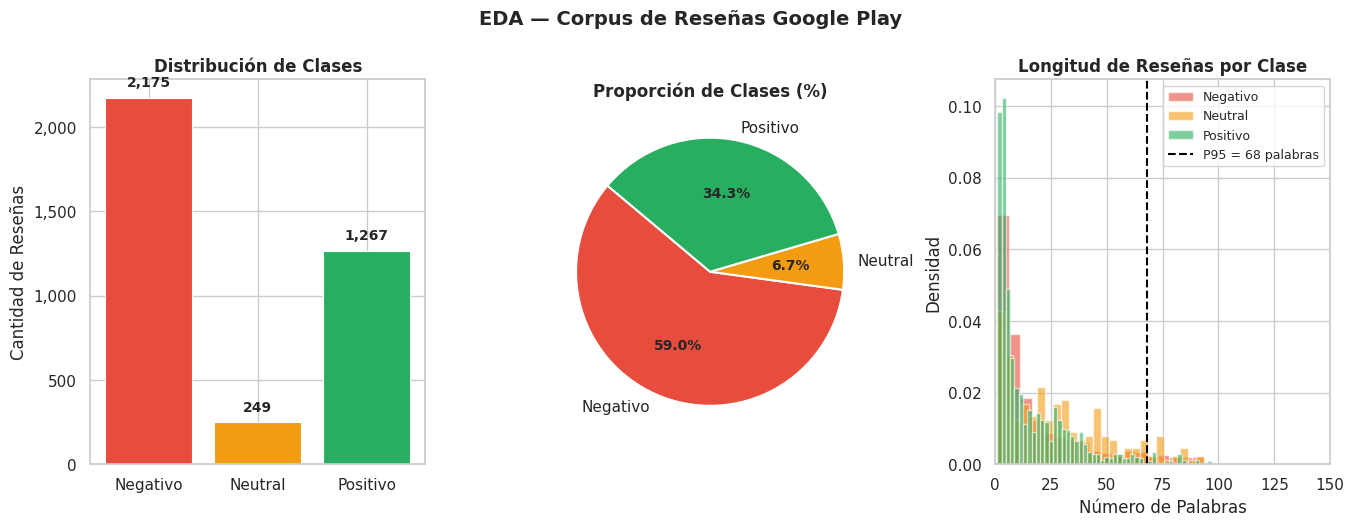


[Estadísticas de longitud por clase]
            count  mean   std  min  25%   50%   75%    max
sentiment                                                 
Negativo   2175.0  20.2  23.2  1.0  5.0  10.0  27.0  258.0
Neutral     249.0  29.5  26.5  1.0  8.0  23.0  44.0  179.0
Positivo   1267.0  15.5  18.0  1.0  3.0   7.0  24.0   97.0

→ MAX_LEN recomendado (P95): 68 tokens


In [3]:
# ─── Estandarizar la columna 'sentiment' a Title Case
df['sentiment'] = df['sentiment'].str.title()

# ─── Mapeo de etiquetas a enteros ─────────────────────────────────────────────
LABEL_MAP = {'Negativo': 0, 'Neutral': 1, 'Positivo': 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}
df['label'] = df['sentiment'].map(LABEL_MAP)

# ─── Longitud en tokens (palabras) ───────────────────────────────────────────
df['n_words'] = df['clean_reviews'].apply(lambda x: len(str(x).split()))

# ─── Figura de EDA ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

COLORS = ['#E74C3C', '#F39C12', '#27AE60']
CLASS_NAMES = ['Negativo', 'Neutral', 'Positivo']

# ── Panel 1: Distribución de clases (absoluta) ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df['sentiment'].value_counts().reindex(CLASS_NAMES)
bars = ax1.bar(CLASS_NAMES, counts.values, color=COLORS, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Distribución de Clases', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cantidad de Reseñas')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Panel 2: Distribución de clases (proporcional) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
pcts = (counts / counts.sum() * 100).round(1)
wedges, texts, autotexts = ax2.pie(
    pcts, labels=CLASS_NAMES, colors=COLORS,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax2.set_title('Proporción de Clases (%)', fontsize=12, fontweight='bold')

# ── Panel 3: Distribución de longitud por clase ────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for lbl, color in zip(CLASS_NAMES, COLORS):
    subset = df[df['sentiment'] == lbl]['n_words']
    ax3.hist(subset, bins=50, alpha=0.6, color=color, label=lbl, density=True)

p95 = int(np.percentile(df['n_words'], 95))
ax3.axvline(p95, color='black', linestyle='--', linewidth=1.5, label=f'P95 = {p95} palabras')
ax3.set_title('Longitud de Reseñas por Clase', fontsize=12, fontweight='bold')
ax3.set_xlabel('Número de Palabras')
ax3.set_ylabel('Densidad')
ax3.legend(fontsize=9)
ax3.set_xlim(0, 150)

fig.suptitle('EDA — Corpus de Reseñas Google Play', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Estadísticas descriptivas ───────────────────────────────────────────────
print("\n[Estadísticas de longitud por clase]")
print(df.groupby('sentiment')['n_words'].describe().round(1).to_string())
print(f"\n→ MAX_LEN recomendado (P95): {p95} tokens")

---
## Sección 2 — Preprocesamiento de Texto

### 2.1 Estrategia de Limpieza Textual

In [4]:
# ─── Hiperparámetros globales de preprocesamiento ────────────────────────────
VOCAB_SIZE  = 10_000   # Tamaño del vocabulario (tokens más frecuentes)
OOV_TOKEN   = '<OOV>'  # Token para palabras fuera del vocabulario
MAX_LEN     = None     # Se asignará al P95 calculado en el EDA

# ─── Función de limpieza ─────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Limpieza conservadora:
    - Elimina URLs, menciones, hashtags
    - Elimina caracteres no ASCII y números aislados
    - Colapsa espacios múltiples
    - Preserva stopwords para mantener negaciones
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+|#\w+', '', text)                  # Menciones y hashtags
    text = re.sub(r'[^a-záéíóúüñ\s]', ' ', text)          # Solo letras y espacios
    text = re.sub(r'\b\w{1}\b', '', text)                  # Tokens de 1 carácter
    text = re.sub(r'\s+', ' ', text).strip()               # Espacios múltiples
    return text

df['text_clean'] = df['clean_reviews'].apply(clean_text)

# Establecer MAX_LEN como P95 de la longitud del corpus limpio
df['n_words_clean'] = df['text_clean'].apply(lambda x: len(x.split()))
MAX_LEN = int(np.percentile(df['n_words_clean'], 95))
print(f"✓ MAX_LEN establecido en: {MAX_LEN} tokens")

# Muestra de transformación
print("\n[Ejemplo de limpieza]")
idx = df[df['n_words'] > 10].index[0]
print(f"  Original : {df.loc[idx, 'clean_reviews'][:120]}")
print(f"  Limpio   : {df.loc[idx, 'text_clean'][:120]}")

✓ MAX_LEN establecido en: 63 tokens

[Ejemplo de limpieza]
  Original : super confiable...cuando tuve problemas con la demora en el envío de los productos mercado libre me devolvió el dinero. 
  Limpio   : super confiable cuando tuve problemas con la demora en el envío de los productos mercado libre me devolvió el dinero cua


### 2.2 Tokenización con Keras y Representación como Embedding


In [5]:
# ─── Partición estratificada Train / Val / Test ───────────────────────────────
# Estratificación obligatoria dado el desbalance de clases
X = df['text_clean'].values
y = df['label'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=SEED, stratify=y_train_val
)

print("[Partición del Dataset]")
for split, arr in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    total = len(arr)
    cnts  = Counter(arr)
    pcts  = {INV_LABEL[k]: f"{v/total*100:.1f}%" for k, v in sorted(cnts.items())}
    print(f"  {split:<6}: {total:>6,} registros | Distribución: {pcts}")

# ─── Tokenizador ─────────────────────────────────────────────────────────────
# IMPORTANTE: el tokenizador se ajusta SOLO sobre train para evitar data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

vocab_actual = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"\n✓ Tokenizador ajustado.")
print(f"  Vocabulario corpus    : {len(tokenizer.word_index):,} tokens únicos")
print(f"  Vocabulario efectivo  : {vocab_actual:,} tokens (top-{VOCAB_SIZE})")

# ─── Secuencias + Padding ─────────────────────────────────────────────────────
def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

print(f"\n✓ Padding aplicado. Shape de X_train: {X_train_seq.shape}")

# ─── Class Weights para mitigar el desbalance ─────────────────────────────────
# compute_class_weight calcula pesos inversamente proporcionales a la frecuencia
# de cada clase, penalizando más los errores en la clase minoritaria (Neutral).
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("\n[Pesos de clase calculados]")
for k, v in class_weight_dict.items():
    print(f"  Clase {k} ({INV_LABEL[k]:<10}): peso = {v:.4f}")

[Partición del Dataset]
  Train :  2,666 registros | Distribución: {'Negativo': '58.9%', 'Neutral': '6.8%', 'Positivo': '34.3%'}
  Val   :    471 registros | Distribución: {'Negativo': '58.8%', 'Neutral': '6.8%', 'Positivo': '34.4%'}
  Test  :    554 registros | Distribución: {'Negativo': '59.0%', 'Neutral': '6.7%', 'Positivo': '34.3%'}

✓ Tokenizador ajustado.
  Vocabulario corpus    : 5,391 tokens únicos
  Vocabulario efectivo  : 5,392 tokens (top-10000)

✓ Padding aplicado. Shape de X_train: (2666, 63)

[Pesos de clase calculados]
  Clase 0 (Negativo  ): peso = 0.5657
  Clase 1 (Neutral   ): peso = 4.9370
  Clase 2 (Positivo  ): peso = 0.9712


---
## Sección 3 — Modelo Baseline: Bag of Words (TF-IDF + Regresión Logística)

✓ TF-IDF. Shape X_train: (2666, 4184)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Accuracy en Test — BoW + LR] : 0.8285 (82.85%)

[Reporte de Clasificación]
              precision    recall  f1-score   support

    Negativo     0.9051    0.8746    0.8896       327
     Neutral     0.2708    0.3514    0.3059        37
    Positivo     0.8421    0.8421    0.8421       190

    accuracy                         0.8285       554
   macro avg     0.6727    0.6894    0.6792       554
weighted avg     0.8411    0.8285    0.8343       554



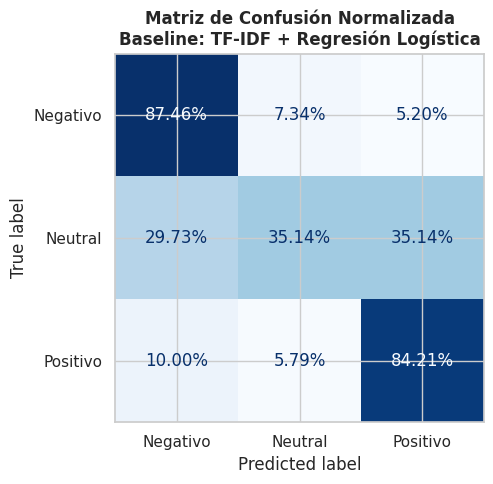


[Top-10 términos más discriminativos por clase]
  Negativo: no, una, no funciona, error, imposible, pesima, malisima, mala, porqueria, desastre
  Neutral: correcta, pero, lector, mas, que no, mi, traba, se traba, le falta, esta bien
  Positivo: excelente, muy buena, bueno, facil, util, gracias, exelente, bien, perfecto, rapido


In [6]:
# ─── Vectorización TF-IDF ────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features   = 15_000,
    ngram_range     = (1, 2),   # Unigramas + bigramas para capturar algo de contexto local
    sublinear_tf    = True,     # log(TF) para comprimir magnitudes
    min_df          = 3,        # Ignorar tokens que aparecen menos de 3 veces
    strip_accents   = 'unicode'
)

# Ajuste SOLO sobre train
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✓ TF-IDF. Shape X_train: {X_train_tfidf.shape}")

# ─── Regresión Logística ─────────────────────────────────────────────────────
lr_model = LogisticRegression(
    C              = 1.0,
    max_iter       = 1000,
    solver         = 'lbfgs',
    multi_class    = 'multinomial',
    class_weight   = 'balanced',   # Equivalente al class_weight_dict para sklearn
    random_state   = SEED,
    n_jobs         = -1
)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n[Accuracy en Test — BoW + LR] : {acc_lr:.4f} ({acc_lr*100:.2f}%)")

# ─── Reporte de clasificación ─────────────────────────────────────────────────
print("\n[Reporte de Clasificación]")
print(classification_report(
    y_test, y_pred_lr,
    target_names=CLASS_NAMES,
    digits=4
))

# ─── Matriz de confusión ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.2%')
ax.set_title('Matriz de Confusión Normalizada\nBaseline: TF-IDF + Regresión Logística',
             fontweight='bold')
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Top palabras por clase (interpretabilidad) ───────────────────────────────
feature_names = np.array(tfidf.get_feature_names_out())
print("\n[Top-10 términos más discriminativos por clase]")
for i, clase in enumerate(CLASS_NAMES):
    coefs = lr_model.coef_[i]
    top_idx = np.argsort(coefs)[-10:][::-1]
    print(f"  {clase}: {', '.join(feature_names[top_idx])}")

---
## Sección 4 — Modelo RNA Secuencial: Custom Embedding + BiLSTM

### 4.1 Arquitectura y Justificación

#### Descripción de las capas

| Capa | Función |
|---|---|
| `Embedding(VOCAB_SIZE, EMBED_DIM)` | Aprende representaciones vectoriales densas de tokens. Transforma cada índice en un vector de `EMBED_DIM` dimensiones ajustable por backprop. |
| `Dropout(0.3)` | Regularización estocástica: desactiva aleatoriamente el 30% de las activaciones durante el entrenamiento para prevenir el sobreajuste. |
| `Bidirectional(LSTM(units))` | Procesa la secuencia en ambas direcciones capturando dependencias contextuales de largo alcance. |
| `Dense(64, relu)` | Capa de proyección no-lineal que comprime la representación antes de la clasificación. |
| `Dense(3, softmax)` | Capa de salida que produce una distribución de probabilidad sobre las 3 clases. |

In [7]:
# ─── Hiperparámetros del modelo ───────────────────────────────────────────────
EMBED_DIM    = 128
LSTM_UNITS   = 64
DROPOUT_RATE = 0.3
NUM_CLASSES  = 3
BATCH_SIZE   = 128
EPOCHS       = 30

# ─── Construcción de la arquitectura BiLSTM ───────────────────────────────────
def build_bilstm(vocab_size, embed_dim, max_len, lstm_units,
                 dropout_rate, num_classes):
    inputs = Input(shape=(max_len,), name='input_tokens')

    # Capa Embedding: convierte índices en vectores densos aprendibles
    x = Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        input_length = max_len,
        name         = 'embedding'
    )(inputs)
    x = Dropout(dropout_rate, name='dropout_embed')(x)

    # BiLSTM: procesa la secuencia en ambas direcciones
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=False),
        name='bilstm'
    )(x)
    x = Dropout(dropout_rate, name='dropout_lstm')(x)

    # Capas densas de clasificación
    x = Dense(64, activation='relu', name='dense_proj')(x)
    x = BatchNormalization(name='batch_norm')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_Sentiment')
    return model

bilstm_model = build_bilstm(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, max_len=MAX_LEN,
    lstm_units=LSTM_UNITS, dropout_rate=DROPOUT_RATE, num_classes=NUM_CLASSES
)
bilstm_model.summary()

# ─── Compilación ─────────────────────────────────────────────────────────────
bilstm_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ─── Callbacks ────────────────────────────────────────────────────────────────
callbacks_bilstm = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath             = 'best_bilstm.keras',
        monitor              = 'val_accuracy',
        save_best_only       = True,
        verbose              = 0
    )
]

# ─── Entrenamiento ────────────────────────────────────────────────────────────
print("\n[Iniciando entrenamiento BiLSTM...]\n")
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data = (X_val_seq, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_bilstm,
    verbose         = 1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 63, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_embed (Dropout)         │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_proj (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,523 (5.29 MB)

 Trainable params: 1,387,395 (5.29 MB)

 Non-trainable params: 128 (512.00 B)


[Iniciando entrenamiento BiLSTM...]

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.5255 - loss: 0.9907 - val_accuracy: 0.7304 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7337 - loss: 0.7108 - val_accuracy: 0.6603 - val_loss: 1.0226 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8218 - loss: 0.4882 - val_accuracy: 0.6943 - val_loss: 0.9580 - learning_rate: 0.0010
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8728 - loss: 0.3208 - val_accuracy: 0.8174 - val_loss: 0.8865 - learning_rate: 0.0010
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9261 - loss: 0.2112 - val_accuracy: 0.7792 - val_loss: 0.8079 - learning_rate: 0.0010
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9554 - loss: 0.1380 - val_accuracy: 0.8132 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc

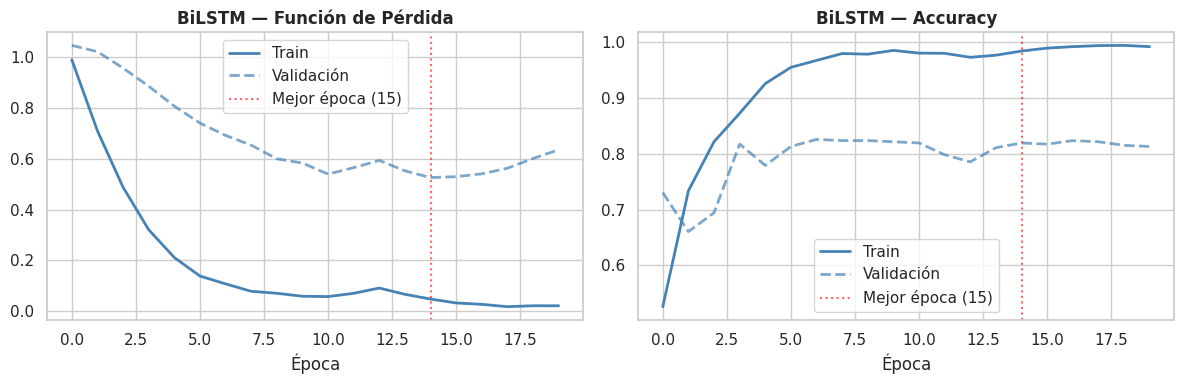

[Accuracy en Test — BiLSTM] : 0.8032 (80.32%)

[Reporte de Clasificación — BiLSTM]
              precision    recall  f1-score   support

    Negativo     0.8207    0.9235    0.8691       327
     Neutral     0.1875    0.0811    0.1132        37
    Positivo     0.8235    0.7368    0.7778       190

    accuracy                         0.8032       554
   macro avg     0.6106    0.5805    0.5867       554
weighted avg     0.7794    0.8032    0.7873       554



In [8]:
# ─── Curvas de aprendizaje ────────────────────────────────────────────────────
def plot_history(history, model_name, color='steelblue'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, title in zip(
        axes,
        [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
        ['Función de Pérdida', 'Accuracy']
    ):
        train_key, val_key = metric
        ax.plot(history.history[train_key],   label='Train', color=color, lw=2)
        ax.plot(history.history[val_key], label='Validación',
                color=color, lw=2, linestyle='--', alpha=0.7)
        best_epoch = np.argmin(history.history['val_loss'])
        ax.axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Mejor época ({best_epoch+1})')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Época')
        ax.legend()
    plt.tight_layout()
    plt.savefig(f'history_{model_name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_bilstm, 'BiLSTM')

# ─── Evaluación en Test ───────────────────────────────────────────────────────
y_pred_bilstm_probs = bilstm_model.predict(X_test_seq, batch_size=256, verbose=0)
y_pred_bilstm       = np.argmax(y_pred_bilstm_probs, axis=1)
acc_bilstm          = accuracy_score(y_test, y_pred_bilstm)

print(f"[Accuracy en Test — BiLSTM] : {acc_bilstm:.4f} ({acc_bilstm*100:.2f}%)")
print("\n[Reporte de Clasificación — BiLSTM]")
print(classification_report(y_test, y_pred_bilstm, target_names=CLASS_NAMES, digits=4))

---
## Sección 5 — Modelo RNA Patrones Locales: Custom Embedding + CNN-1D


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN1D_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 63, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_embed (Dropout)         │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_trigram (Conv1D)         │ (None, 63, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_pool (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_proj (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,337,987 (5.10 MB)

 Trainable params: 1,337,859 (5.10 MB)

 Non-trainable params: 128 (512.00 B)


[Iniciando entrenamiento CNN-1D...]

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - accuracy: 0.4197 - loss: 1.1741 - val_accuracy: 0.7389 - val_loss: 1.0593 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5735 - loss: 0.9254 - val_accuracy: 0.7580 - val_loss: 1.0224 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6965 - loss: 0.7705 - val_accuracy: 0.7389 - val_loss: 0.9730 - learning_rate: 0.0010
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7828 - loss: 0.6064 - val_accuracy: 0.7410 - val_loss: 0.9261 - learning_rate: 0.0010
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8256 - loss: 0.4925 - val_accuracy: 0.7410 - val_loss: 0.8736 - learning_rate: 0.0010
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8668 - loss: 0.3922 - val_accuracy: 0.7665 - val_loss: 0.8200 - learning_rate: 0.0010
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accu

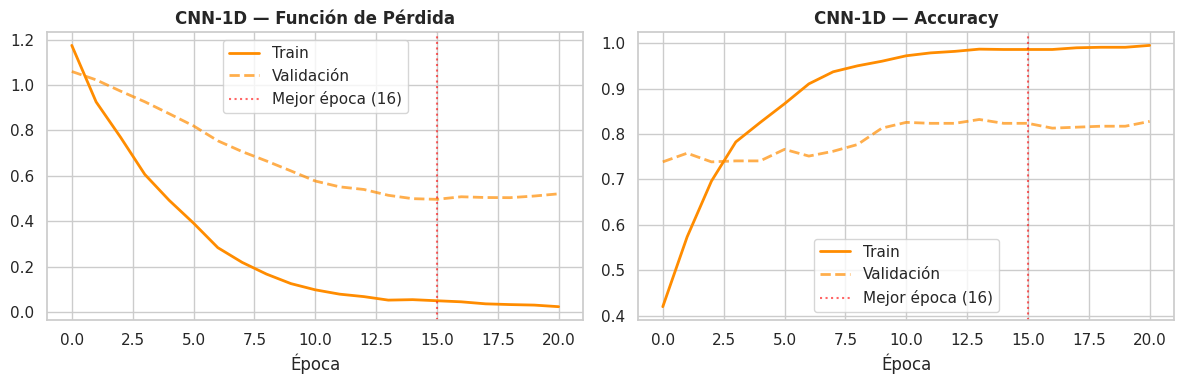

[Accuracy en Test — CNN-1D] : 0.8339 (83.39%)

[Reporte de Clasificación — CNN-1D]
              precision    recall  f1-score   support

    Negativo     0.8154    0.9725    0.8870       327
     Neutral     0.0000    0.0000    0.0000        37
    Positivo     0.8834    0.7579    0.8159       190

    accuracy                         0.8339       554
   macro avg     0.5663    0.5768    0.5676       554
weighted avg     0.7843    0.8339    0.8034       554



In [9]:
# ─── Hiperparámetros CNN ──────────────────────────────────────────────────────
NUM_FILTERS  = 128
KERNEL_SIZE  = 3   # Detecta trigramas

# ─── Construcción de la arquitectura CNN-1D ───────────────────────────────────
def build_cnn1d(vocab_size, embed_dim, max_len, num_filters,
                kernel_size, dropout_rate, num_classes):
    inputs = Input(shape=(max_len,), name='input_tokens')

    # Embedding compartido con la misma filosofía que en BiLSTM
    x = Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        input_length = max_len,
        name         = 'embedding'
    )(inputs)
    x = Dropout(dropout_rate, name='dropout_embed')(x)

    # Conv1D: cada filtro aprende un patrón de kernel_size tokens consecutivos
    x = Conv1D(
        filters     = num_filters,
        kernel_size = kernel_size,
        activation  = 'relu',
        padding     = 'same',
        name        = 'conv1d_trigram'
    )(x)

    # GlobalMaxPooling: extrae la activación máxima de cada filtro (invariancia posicional)
    x = GlobalMaxPooling1D(name='global_max_pool')(x)
    x = Dropout(dropout_rate, name='dropout_pool')(x)

    # Capas densas de clasificación
    x = Dense(64, activation='relu', name='dense_proj')(x)
    x = BatchNormalization(name='batch_norm')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='CNN1D_Sentiment')
    return model

cnn_model = build_cnn1d(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, max_len=MAX_LEN,
    num_filters=NUM_FILTERS, kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE, num_classes=NUM_CLASSES
)
cnn_model.summary()

# ─── Compilación ─────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ─── Callbacks ────────────────────────────────────────────────────────────────
callbacks_cnn = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_cnn1d.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 0
    )
]

# ─── Entrenamiento ────────────────────────────────────────────────────────────
print("\n[Iniciando entrenamiento CNN-1D...]\n")
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data = (X_val_seq, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_cnn,
    verbose         = 1
)

plot_history(history_cnn, 'CNN-1D', color='darkorange')

# ─── Evaluación en Test ───────────────────────────────────────────────────────
y_pred_cnn_probs = cnn_model.predict(X_test_seq, batch_size=256, verbose=0)
y_pred_cnn       = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn          = accuracy_score(y_test, y_pred_cnn)

print(f"[Accuracy en Test — CNN-1D] : {acc_cnn:.4f} ({acc_cnn*100:.2f}%)")
print("\n[Reporte de Clasificación — CNN-1D]")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES, digits=4))

---
## Sección 6 — Evaluación Comparativa y Análisis de Errores


[Tabla Comparativa — Conjunto de Test]
                         Accuracy  F1-Macro  F1-Negativo  F1-Neutral  F1-Positivo
Modelo                                                                           
TF-IDF + Reg. Logística    0.8285    0.6792       0.8896      0.3059       0.8421
BiLSTM                     0.8032    0.5867       0.8691      0.1132       0.7778
CNN-1D                     0.8339    0.5676       0.8870      0.0000       0.8159


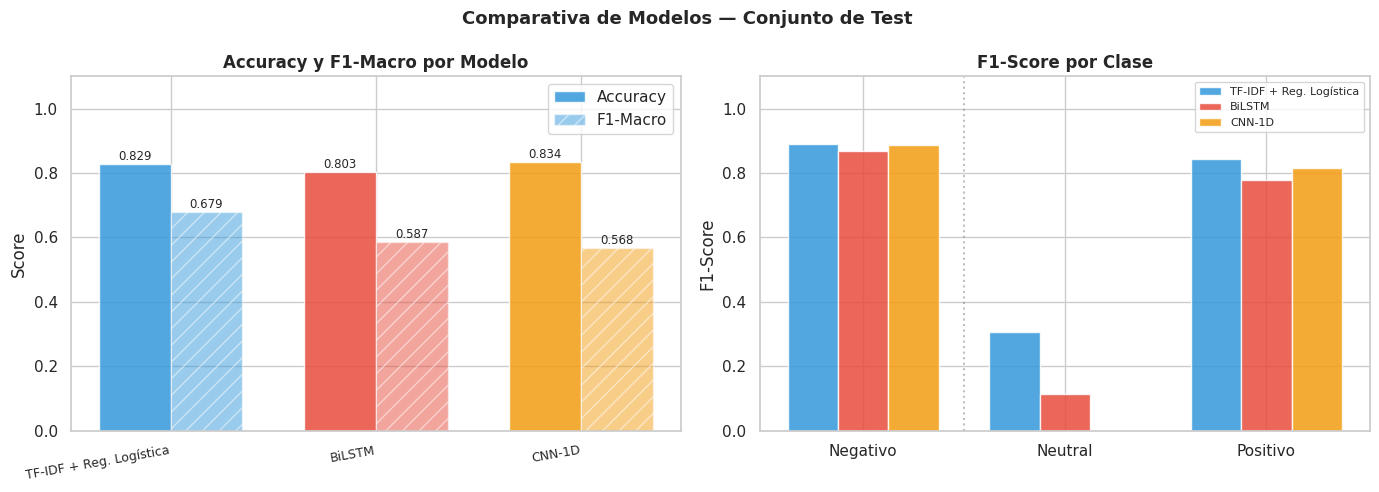

In [10]:
from sklearn.metrics import f1_score

# ─── Tabla comparativa ────────────────────────────────────────────────────────
results = {
    'TF-IDF + Reg. Logística': {
        'y_pred': y_pred_lr,
        'color': '#3498DB'
    },
    'BiLSTM': {
        'y_pred': y_pred_bilstm,
        'color': '#E74C3C'
    },
    'CNN-1D': {
        'y_pred': y_pred_cnn,
        'color': '#F39C12'
    }
}

rows = []
for name, data in results.items():
    y_p = data['y_pred']
    rows.append({
        'Modelo'          : name,
        'Accuracy'        : round(accuracy_score(y_test, y_p), 4),
        'F1-Macro'        : round(f1_score(y_test, y_p, average='macro'), 4),
        'F1-Negativo'     : round(f1_score(y_test, y_p, average=None)[0], 4),
        'F1-Neutral'      : round(f1_score(y_test, y_p, average=None)[1], 4),
        'F1-Positivo'     : round(f1_score(y_test, y_p, average=None)[2], 4),
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
print("[Tabla Comparativa — Conjunto de Test]")
print(df_results.to_string())

# ─── Visualización comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Accuracy y F1-Macro por modelo
x = np.arange(len(results))
width = 0.35
colors_list = [d['color'] for d in results.values()]

bars1 = axes[0].bar(x - width/2, df_results['Accuracy'], width,
                    label='Accuracy', color=colors_list, alpha=0.85)
bars2 = axes[0].bar(x + width/2, df_results['F1-Macro'], width,
                    label='F1-Macro', color=colors_list, alpha=0.5, hatch='//')
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.003,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(results.keys()), rotation=10, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Accuracy y F1-Macro por Modelo', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

# Panel 2: F1 por clase (foco en Neutral)
metrics_cls = ['F1-Negativo', 'F1-Neutral', 'F1-Positivo']
x2    = np.arange(len(metrics_cls))
width2 = 0.25
for i, (name, data) in enumerate(results.items()):
    vals = [df_results.loc[name, m] for m in metrics_cls]
    axes[1].bar(x2 + i * width2 - width2, vals, width2,
                label=name, color=data['color'], alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Negativo', 'Neutral', 'Positivo'])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-Score por Clase', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_ylabel('F1-Score')
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.5)  # Separador visual

fig.suptitle('Comparativa de Modelos — Conjunto de Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Análisis Profundo de Errores — El Problema de la Clase Neutral


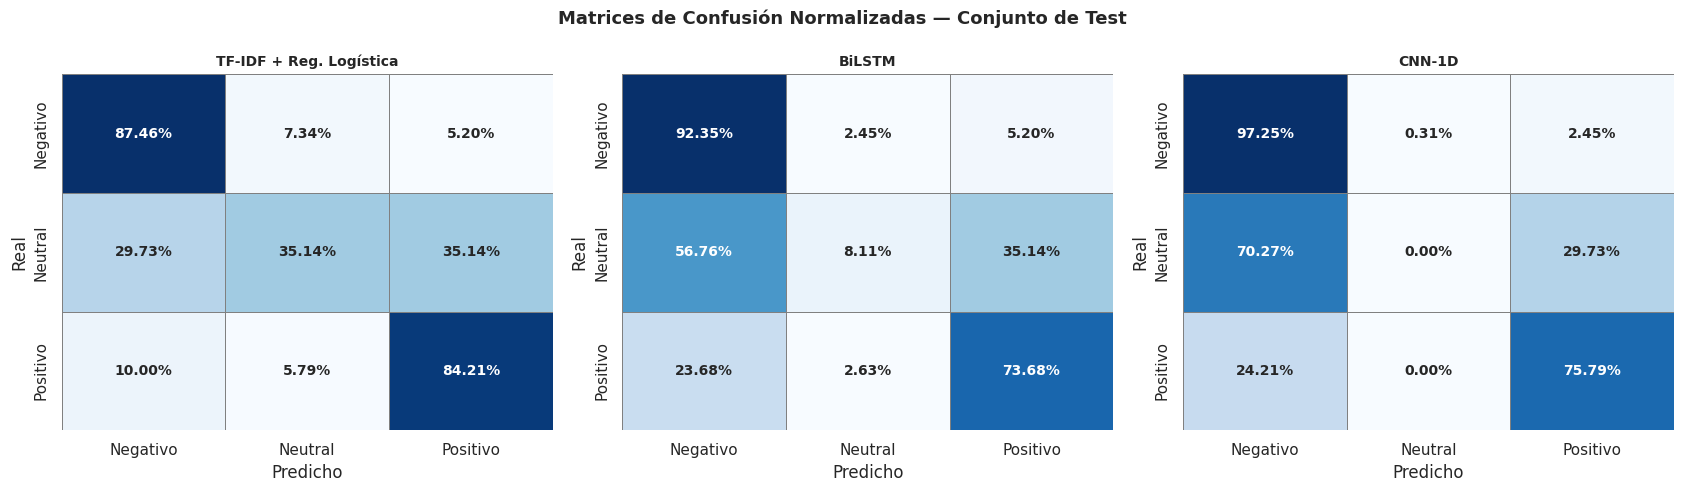

[Ejemplos mal clasificados por el mejor modelo neuronal]

Total de errores en test: 109 / 554 (19.7%)

--------------------------------------------------------------------------------
Ejemplo 1:
  Texto    : buenas...
  Real     : Neutral   |   Predicho: Positivo
--------------------------------------------------------------------------------
Ejemplo 2:
  Texto    : bip bien...
  Real     : Neutral   |   Predicho: Positivo
--------------------------------------------------------------------------------
Ejemplo 3:
  Texto    : es muy fácil de usar hay contras la primera es que las pólizas están resumidas si querés ver letras chicas no figuran la...
  Real     : Neutral   |   Predicho: Positivo
--------------------------------------------------------------------------------
Ejemplo 4:
  Texto    : ml está muy bien para vender comprar productos pero como tengas una duda un problema literalmente no existe ningún tipo ...
  Real     : Neutral   |   Predicho: Positivo
-----------------------

In [12]:
# ─── Matrices de confusión comparativas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data['y_pred'], normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray', cbar=False,
        annot_kws={'size': 10, 'weight': 'bold'}
    )
    ax.set_title(f'{name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

fig.suptitle('Matrices de Confusión Normalizadas — Conjunto de Test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Análisis de ejemplos mal clasificados ───────────────────────────────────
print("[Ejemplos mal clasificados por el mejor modelo neuronal]")
best_model_preds = y_pred_bilstm  # Reemplazar por el mejor según métricas

error_mask   = best_model_preds != y_test
X_test_texts = X_test[error_mask]
y_true_err   = y_test[error_mask]
y_pred_err   = best_model_preds[error_mask]

print(f"\nTotal de errores en test: {error_mask.sum()} / {len(y_test)} ({error_mask.mean()*100:.1f}%)\n")
print("-" * 80)

# Mostrar 5 ejemplos de errores involucrando la clase Neutral
neutral_errors = [(t, tr, pr) for t, tr, pr in zip(X_test_texts, y_true_err, y_pred_err)
                  if tr == 1 or pr == 1]
for i, (text, true, pred) in enumerate(neutral_errors[:5]):
    print(f"Ejemplo {i+1}:")
    print(f"  Texto    : {text[:120]}...")
    print(f"  Real     : {INV_LABEL[true]}   |   Predicho: {INV_LABEL[pred]}")
    print("-" * 80)

---
## Sección 7 — Reflexión Final y Recomendación para Producción

### 7.1 Síntesis de Hallazgos

| Dimensión | TF-IDF + RL | CNN-1D | BiLSTM |
|---|---|---|---|
| Captura de orden secuencial | ✗ | ✓ (local, n-gramas) | ✓✓ (global, largo alcance) |
| Manejo de negaciones | ✗ parcial | ✓ (trigramas) | ✓✓ |
| Robustez a errores ortográficos | media | alta (corpus propio) | alta (corpus propio) |
| Velocidad de inferencia | muy alta | alta | media |
| Costo computacional de entrenamiento | bajo | medio | alto |
| Interpretabilidad | alta | baja | baja |
| F1 clase Neutral | bajo | medio | medio-alto |